In [2]:
from google.colab import drive
import os

# Montage du Drive
drive.mount('/content/drive')

# Création du dossier de projet sur Drive
PROJECT_PATH = '/content/drive/MyDrive/PlantVillage_Project'
os.makedirs(PROJECT_PATH, exist_ok=True)
print(f"Dossier projet prêt : {PROJECT_PATH}")

Mounted at /content/drive
Dossier projet prêt : /content/drive/MyDrive/PlantVillage_Project


Utilisation de l'appareil : cuda
Téléchargement du dataset PlantVillage...
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset téléchargé ici : /kaggle/input/plantvillage-dataset
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]


Début de l'entraînement...
Epoch 1/10 - Train Loss: 0.6103 - Train Acc: 0.8743
Epoch 2/10 - Train Loss: 0.1883 - Train Acc: 0.9570
Epoch 3/10 - Train Loss: 0.1280 - Train Acc: 0.9691
Epoch 4/10 - Train Loss: 0.0988 - Train Acc: 0.9754
Epoch 5/10 - Train Loss: 0.0812 - Train Acc: 0.9791
Epoch 6/10 - Train Loss: 0.0691 - Train Acc: 0.9821
Epoch 7/10 - Train Loss: 0.0600 - Train Acc: 0.9843
Epoch 8/10 - Train Loss: 0.0538 - Train Acc: 0.9859
Epoch 9/10 - Train Loss: 0.0477 - Train Acc: 0.9874
Epoch 10/10 - Train Loss: 0.0424 - Train Acc: 0.9888

Évaluation sur le Test Set...


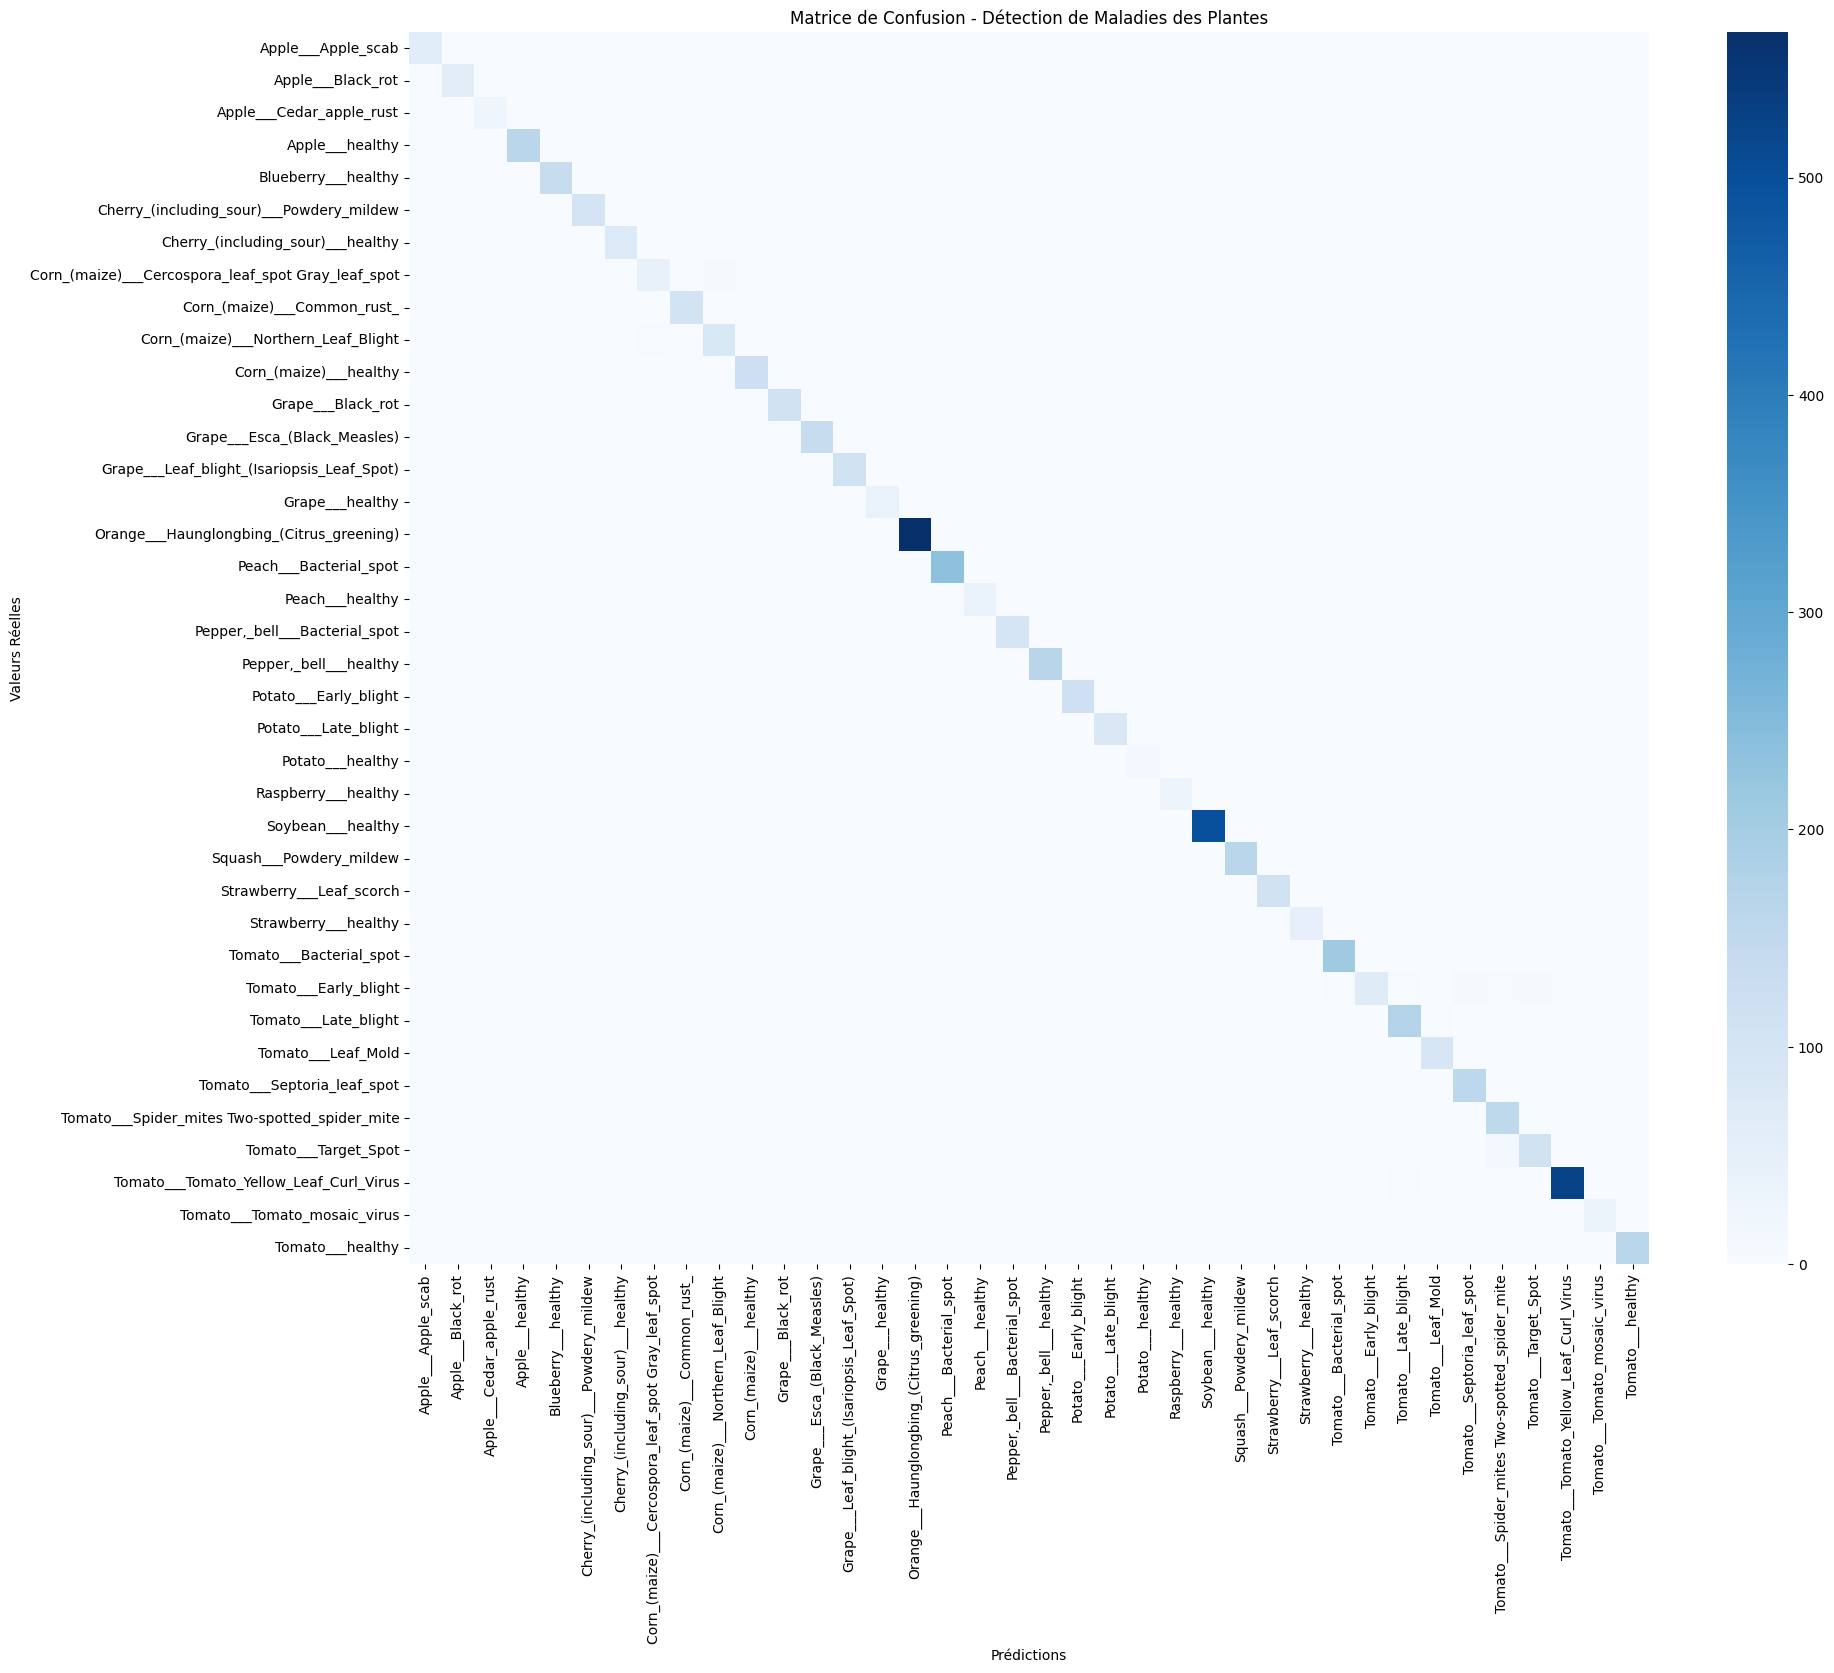


--- Top 5 des paires de maladies les plus confondues ---
1. Vraie classe : 'Tomato___Target_Spot' | Prédite à tort comme : 'Tomato___Spider_mites Two-spotted_spider_mite' (13 fois)
2. Vraie classe : 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot' | Prédite à tort comme : 'Corn_(maize)___Northern_Leaf_Blight' (10 fois)
3. Vraie classe : 'Tomato___Early_blight' | Prédite à tort comme : 'Tomato___Septoria_leaf_spot' (9 fois)
4. Vraie classe : 'Tomato___Early_blight' | Prédite à tort comme : 'Tomato___Target_Spot' (7 fois)
5. Vraie classe : 'Tomato___Late_blight' | Prédite à tort comme : 'Tomato___Spider_mites Two-spotted_spider_mite' (6 fois)


In [1]:
from sklearn.metrics import classification_report

def evaluate_and_plot_confusion(model, loader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Rapport de classification
    print("\n--- Rapport de Classification ---")
    print(classification_report(all_labels, all_preds, target_names=classes))

    # Calcul de la matrice
    cm = confusion_matrix(all_labels, all_preds)

    # Affichage graphique
    plt.figure(figsize=(20, 16))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Prédictions")
    plt.ylabel("Valeurs Réelles")
    plt.title("Matrice de Confusion - Détection de Maladies des Plantes")
    plt.show()

    return cm, all_labels, all_preds

print("\nÉvaluation sur le Test Set...")
cm, true_labels, pred_labels = evaluate_and_plot_confusion(model, test_loader, class_names)


# PARTIE 7 : Exploratory Data Analysis (EDA)
Visualisons la distribution des classes et quelques exemples d'images du dataset.

/tmp/ipykernel_5139/2071116623.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, y='Classe', x='Nombre d\'images', palette='viridis')


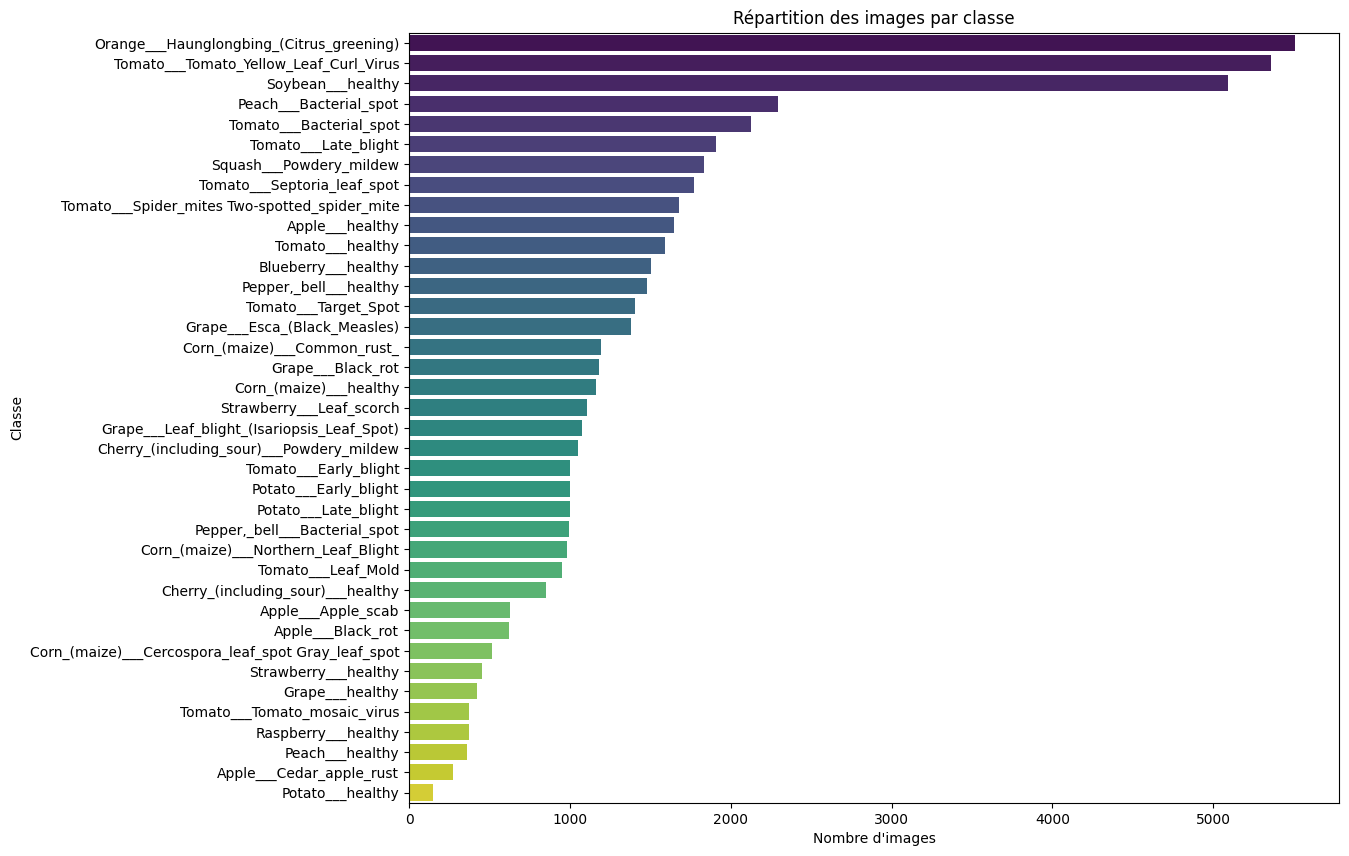

In [3]:
import pandas as pd

# 1. Distribution des classes
counts = {class_name: len(os.listdir(os.path.join(data_dir, class_name))) for class_name in class_names}
df_counts = pd.DataFrame(list(counts.items()), columns=['Classe', 'Nombre d\'images']).sort_values(by='Nombre d\'images', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(data=df_counts, y='Classe', x='Nombre d\'images', palette='viridis')
plt.title('Répartition des images par classe')
plt.show()

Exemples d'images du dataset (après transformations) :


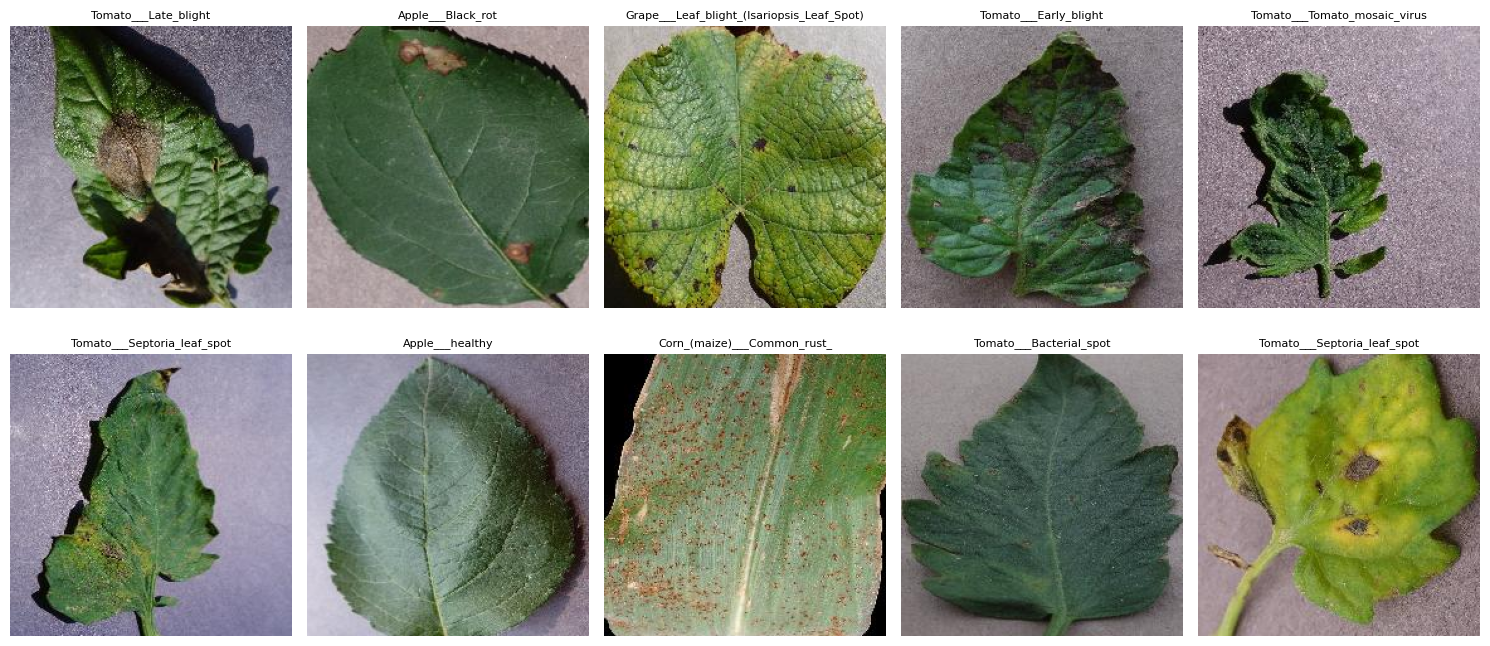

In [4]:
# 2. Visualisation d'échantillons
def show_samples(dataset, num_images=10):
    plt.figure(figsize=(15, 7))
    indices = np.random.choice(len(dataset), num_images, replace=False)
    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        # Denormalize pour l'affichage
        image = image.permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)

        plt.subplot(2, 5, i + 1)
        plt.imshow(image)
        plt.title(class_names[label], fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Exemples d'images du dataset (après transformations) :")
show_samples(train_dataset)

# PARTIE 8 : Sauvegarde du Modèle sur Drive

In [5]:
MODEL_SAVE_PATH = os.path.join(PROJECT_PATH, 'plant_resnet50_v1.pth')
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Modèle sauvegardé avec succès sur Drive : {MODEL_SAVE_PATH}")

Modèle sauvegardé avec succès sur Drive : /content/drive/MyDrive/PlantVillage_Project/plant_resnet50_v1.pth
